In [13]:
!pip install -q kagglehub

In [14]:
import kagglehub

path = kagglehub.dataset_download("salader/dogsvscats")

print("Dataset path:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Dataset path: /kaggle/input/dogsvscats


In [15]:
import os
print(os.listdir(path))

['test', 'train', 'catsvsdogs']


In [16]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, MaxPooling2D, Conv2D, BatchNormalization, Dropout

In [17]:
#Generators
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, 'train'),
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)

)
validation_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, 'test'),
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)

)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [18]:
#Normalize
def process(image, label):
  image = tf.cast(image/255, tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [19]:
#Create a cNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [22]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 98ms/step - accuracy: 0.5946 - loss: 1.4525 - val_accuracy: 0.6596 - val_loss: 0.6336
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6959 - loss: 0.5876 - val_accuracy: 0.7492 - val_loss: 0.5075
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7578 - loss: 0.5024 - val_accuracy: 0.7518 - val_loss: 0.5291
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.8024 - loss: 0.4293 - val_accuracy: 0.7996 - val_loss: 0.4335
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8357 - loss: 0.3682 - val_accuracy: 0.7544 - val_loss: 0.6612
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8640 - loss: 0.3172 - val_accuracy: 0.8370 - val_loss: 0.3887
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.9062 - loss: 0.2342 - val_accuracy: 0.7112 - val_loss: 0.9070
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.9367 - loss: 0.1639 - 

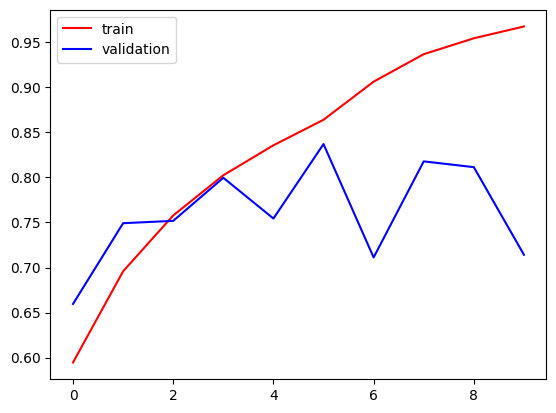

In [23]:
#Overfiting
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

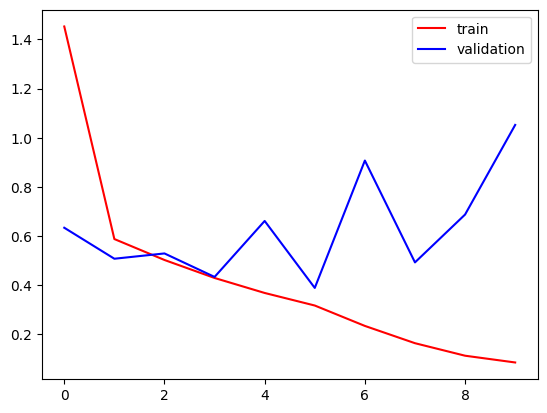

In [24]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [27]:
import cv2

TypeError: Image data of dtype object cannot be converted to float

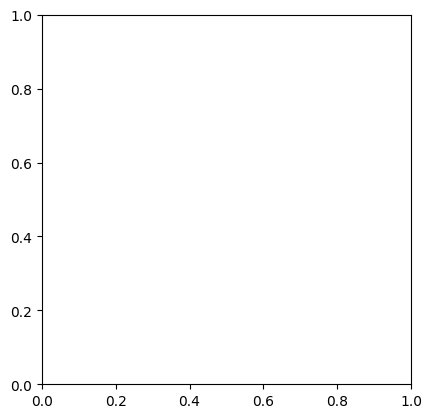

In [32]:
plt.imshow(test_img)

In [34]:
test_img = cv2.imread('/content/images.jpg')


In [36]:
print(test_img)
print(type(test_img))

[[[ 86 140 151]
  [ 86 140 151]
  [ 86 140 151]
  ...
  [ 75 152 145]
  [ 76 153 146]
  [ 76 153 146]]

 [[ 86 140 151]
  [ 86 140 151]
  [ 86 140 151]
  ...
  [ 75 152 145]
  [ 76 153 146]
  [ 76 153 146]]

 [[ 85 139 150]
  [ 85 139 150]
  [ 85 139 150]
  ...
  [ 77 151 147]
  [ 77 151 147]
  [ 78 152 148]]

 ...

 [[ 20  87  56]
  [ 11  78  47]
  [ 17  78  52]
  ...
  [ 79 124  98]
  [ 92 134 109]
  [103 143 118]]

 [[ 23  90  59]
  [ 14  81  50]
  [ 21  82  56]
  ...
  [ 80 125  99]
  [ 93 135 110]
  [103 143 118]]

 [[ 25  92  61]
  [ 17  84  53]
  [ 25  86  60]
  ...
  [ 80 125  99]
  [ 93 135 110]
  [103 143 118]]]
<class 'numpy.ndarray'>


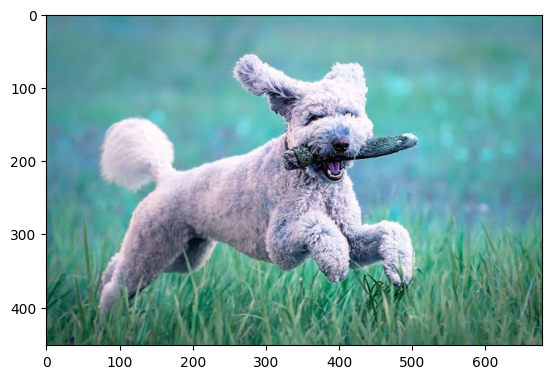

In [37]:
plt.imshow(test_img)

In [39]:
test_img.shape

(452, 678, 3)

In [40]:
test_img = cv2.resize(test_img, (256,256))

In [43]:
test_input = test_img.reshape(1,256,256,3)

In [44]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[1.]], dtype=float32)